# California Housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: target, dtype: float64


In [4]:
print(X.info())
print(X.describe())

print(X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.4

In [5]:

X = X.fillna(X.mean())

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    X[col] = np.clip(X[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [6]:
def standardize(X):
    mean = X.mean()
    std = X.std()
    return (X - mean) / std, mean, std

X_scaled, mean, std = standardize(X)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [8]:
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train = add_bias(X_train.values)
X_test = add_bias(X_test.values)

In [9]:
def initialize_weights(n_features):
    return np.zeros(n_features)

In [10]:
def compute_cost(X, y, w):
    m = len(y)
    predictions = X.dot(w)
    return (1/(2*m)) * np.sum((predictions - y)**2)

In [11]:
def gradient_descent(X, y, w, lr, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(w)
        gradients = (1/m) * X.T.dot(predictions - y)
        w = w - lr * gradients

        cost = compute_cost(X, y, w)
        cost_history.append(cost)

    return w, cost_history

In [12]:
learning_rates = [0.001, 0.01, 0.1]
iterations = 1000

results = {}

for lr in learning_rates:
    w = initialize_weights(X_train.shape[1])
    w, cost_history = gradient_descent(X_train, y_train.values, w, lr, iterations)
    results[lr] = (w, cost_history)

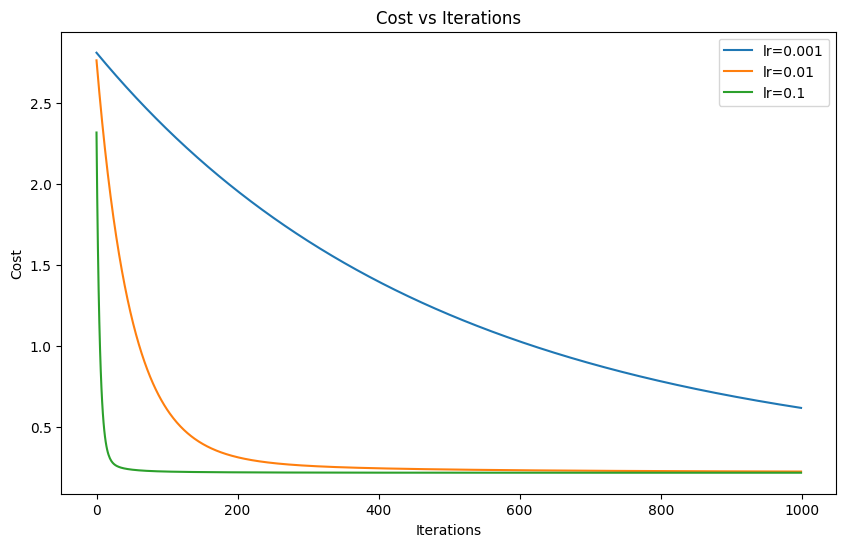

In [13]:
plt.figure(figsize=(10,6))

for lr in learning_rates:
    plt.plot(results[lr][1], label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

In [14]:
def predict(X, w):
    return X.dot(w)

best_lr = 0.01
w_final = results[best_lr][0]

y_pred = predict(X_test, w_final)

In [15]:
def MAE(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def MSE(y, y_pred):
    return np.mean((y - y_pred)**2)

def RMSE(y, y_pred):
    return np.sqrt(MSE(y, y_pred))

def R2(y, y_pred):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    return 1 - (ss_res / ss_total)

print("MAE:", MAE(y_test, y_pred))
print("MSE:", MSE(y_test, y_pred))
print("RMSE:", RMSE(y_test, y_pred))
print("R2:", R2(y_test, y_pred))

MAE: 0.5098170815929781
MSE: 0.47874224138351124
RMSE: 0.6919120185280143
R2: 0.6346619648270592


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Sklearn Results:")
print("MAE:", MAE(y_test, y_pred_sklearn))
print("MSE:", MSE(y_test, y_pred_sklearn))
print("RMSE:", RMSE(y_test, y_pred_sklearn))
print("R2:", R2(y_test, y_pred_sklearn))

Sklearn Results:
MAE: 0.5040585303606504
MSE: 0.46383679188757676
RMSE: 0.6810556452211352
R2: 0.6460366194146243


In [17]:
def stochastic_gradient_descent(X, y, w, lr, epochs):
    m = len(y)
    cost_history = []

    for epoch in range(epochs):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i]

            prediction = xi.dot(w)
            gradient = xi.T * (prediction - yi)

            w = w - lr * gradient.flatten()

        cost = compute_cost(X, y, w)
        cost_history.append(cost)

    return w, cost_history